# 📓 Notebook 3 of 3 — Transfer Models and Full Analysis

**Part of the project:** *Self-Supervised (DINOv2) vs. Supervised CNN Representations for Galaxy Morphology Classification*

| | |
|---|---|
| **Needs** | Notebooks 1 and 2 finished, with their files in `MyDrive/galaxy_project/<full or quick>/` |
| **This notebook does** | Trains **Model 4 — ResNet-18 (ImageNet fine-tuned)** and **Model 5 — DINOv2 (fine-tuned)**, then runs **all analysis** (Steps 8 – 18) on the results of all five models |
| **Steps covered** | 1 (short), 5 (reload), 6d, 6e, 7a, 7c, 8 – 18, Limitations, References |
| **Saves to Google Drive** | `records_nb3_final.pkl` (all five models), every figure in `figures/`, every table in `results/` |
| **Runtime** | Google Colab, **T4 GPU** (needed for the training loop in Step 7c; the analysis afterwards is light) |

**If Colab disconnects:** reconnect and run the notebook again from the top. Finished runs are loaded from Drive and skipped; when everything is finished, the training cell completes in seconds and the analysis runs.

**Research questions answered in this notebook**

| # | Research question | Answered in |
|---|---|---|
| RQ1 | With all labels available, how does a frozen DINOv2 + MLP probe compare with a supervised ResNet-18? | Steps 8, 9 |
| RQ2 | As labels become scarce (100% → 1%), does the self-supervised model lose less accuracy than the supervised CNN? | Steps 8, 9 |
| RQ3 | Does a non-linear (MLP) probe beat a plain linear probe on the same frozen features? | Steps 9, 16 |
| RQ4 | Does fine-tuning the last transformer blocks of DINOv2 help further? | Step 16 |
| RQ5 | Which morphology classes are easy or hard, and which pairs are confused? | Steps 10 – 12 |
| RQ6 | What does each approach cost in parameters, training time, inference time and GPU memory? | Step 15 |

## Key Terms in Plain Language

| Term | Meaning in simple words |
|---|---|
| **Galaxy morphology** | The visible shape and structure of a galaxy — for example round, spiral or edge-on disc. |
| **Galaxy Zoo 2 (GZ2)** | A citizen-science project in which volunteers answered a series of questions about each galaxy image. |
| **Vote fraction** | The share of volunteers who chose a particular answer. *Debiased* means it has been adjusted so that faint or distant galaxies are not unfairly labelled. |
| **Supervised learning** | Learning from examples that come with human-given labels ("this is a spiral"). |
| **Self-supervised learning (SSL)** | Learning useful patterns from images *without* any labels, by solving a puzzle that the images themselves provide. |
| **DINOv2** | A self-supervised model from Meta AI that learns general-purpose image features from a very large collection of ordinary photographs. |
| **Vision Transformer (ViT-S/14)** | A network design that cuts an image into small square patches (here 14 × 14 pixels) and studies how the patches relate to one another. "S" stands for the small version. |
| **Backbone** | The main part of a network that converts an image into numbers. |
| **Embedding (feature vector)** | The list of numbers (384 for this model) that summarises what the network "sees" in one image. |
| **Frozen** | The weights are locked and are not changed during our training. |
| **Probe (linear / MLP)** | A small classifier trained on top of frozen embeddings. *Linear* = a single layer. *MLP* (multi-layer perceptron) = one extra hidden layer with a non-linear step, so it can learn more complex decision boundaries. |
| **Fine-tuning** | Continuing to train some of the pretrained weights on our own task, usually with a small learning rate. |
| **ResNet-18** | A classic 18-layer convolutional neural network (CNN). *From scratch* = random starting weights. *ImageNet-pretrained* = starts from weights already learnt on the ImageNet photo collection. |
| **Label efficiency** | How well a model performs when only a small share of the training labels is available. |
| **Data augmentation** | Creating slightly changed copies of training images (flips, rotations) so that the model learns to ignore changes that do not matter. |
| **Class imbalance and class weights** | Some classes have far fewer images than others. Class weights make mistakes on rare classes count more during training. |
| **Stratified sampling / split** | Picking images class by class so that every class is represented in the right proportion. |
| **Train / validation / test set** | *Train*: the model learns from it. *Validation*: kept aside for tuning choices. *Test*: used only at the end for an honest evaluation. |
| **Accuracy** | The share of galaxies classified correctly. |
| **Precision, recall, F1** | *Precision*: of the galaxies predicted as class X, how many really are X. *Recall*: of the galaxies that really are X, how many were found. *F1*: one score that combines both. **Macro-F1** is the simple average of F1 over all classes, so rare classes count equally. |
| **Mean ± std, 95% CI** | *Mean*: average over seeds. *Std*: how much the results vary between seeds. *95% CI*: the range in which the true average is expected to lie with 95% confidence. |
| **p-value, paired t-test, Wilcoxon test** | The p-value is the chance of seeing a difference at least this large if the two models were actually equal; below 0.05 suggests a real difference. Both tests compare two models seed by seed; the Wilcoxon test does not assume that the differences follow a bell curve. |
| **Confusion matrix** | A table of true class versus predicted class; the diagonal shows correct predictions. |
| **t-SNE** | A method that squeezes high-dimensional embeddings into a 2-D picture; points that are close together are similar. |
| **Attention map** | A picture showing which parts of the image the transformer pays most attention to. |

## Step 1 — Setup (short version)

**Why?** A new session starts empty. **What?** Load the libraries, connect Google Drive, read `config.json` (settings fixed in Notebook 1) and choose the GPU. **How?** Set `RUN_NAME` to the mode used in Notebook 1. `MAX_SESSION_MINUTES` optionally stops the training loop cleanly after a given time. `ALLOW_PARTIAL_ANALYSIS` is normally `False`: the analysis in Steps 8 – 18 then refuses to run until all five models are complete, so that half-finished results are never mistaken for final ones.

In [1]:
import os, time, random, math, json, gc, pickle, shutil, zipfile
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              confusion_matrix, classification_report)
from scipy import stats as sstats
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if DEVICE.type != "cuda":
    print("⚠️  No GPU found. Use Runtime -> Change runtime type -> T4 GPU, then run this notebook again.")

# ============================ SETTINGS FOR THIS NOTEBOOK ============================
RUN_NAME = "full"            # MUST match Notebook 1:  "quick" if QUICK_MODE was True there, else "full"
MAX_SESSION_MINUTES = None   # optional graceful stop, e.g. 240 = stop starting new runs after 4 hours
ALLOW_PARTIAL_ANALYSIS = False   # keep False for the final run; True only to peek at incomplete results
# ====================================================================================

# ---- Google Drive: this is where Notebook 1's results are waiting ----
from google.colab import drive
drive.mount("/content/drive")
PROJECT_DIR = f"/content/drive/MyDrive/galaxy_project/{RUN_NAME}"
FIG_DIR     = f"{PROJECT_DIR}/figures"
RES_DIR     = f"{PROJECT_DIR}/results"
for d in (FIG_DIR, RES_DIR):
    os.makedirs(d, exist_ok=True)

CFG_PATH = f"{PROJECT_DIR}/config.json"
assert os.path.exists(CFG_PATH), (
    f"{CFG_PATH} not found. Run Notebook 1 first, and check that RUN_NAME ('{RUN_NAME}') "
    f"matches the mode used there ('quick' or 'full').")
with open(CFG_PATH) as f:
    cfg = json.load(f)
assert cfg.get("notebook1_finished"), "Notebook 1 did not finish -- run it to the end first."

# Every setting below is READ from Notebook 1 -- do not change them here.
QUICK_MODE   = cfg["quick_mode"]
SEEDS        = cfg["seeds"]
FRACTIONS    = cfg["fractions"]
CNN_EPOCHS   = cfg["cnn_epochs"]
FT_EPOCHS    = cfg["ft_epochs"]
PROBE_EPOCHS = cfg["probe_epochs"]
CLASS_NAMES  = cfg["class_names"]
N_CLASSES    = len(CLASS_NAMES)
IMG_SIZE     = cfg["img_size"]
CLASS_WEIGHTS = torch.tensor(cfg["class_weights"], dtype=torch.float32).to(DEVICE)
print(f"Loaded config: QUICK_MODE={QUICK_MODE} | seeds={SEEDS} | fractions={FRACTIONS} | "
      f"CNN epochs={CNN_EPOCHS} | FT epochs={FT_EPOCHS}")

Using device: cuda
Mounted at /content/drive
Loaded config: QUICK_MODE=False | seeds=[0, 1, 2, 3, 4] | fractions=[0.01, 0.05, 0.1, 0.25, 0.5, 1.0] | CNN epochs=15 | FT epochs=8


In [2]:
# ---- Helpers that make every experiment loop RESUMABLE ---------------------------------------
# After every finished run the full list of results ("records") is written to Google Drive.
# If Colab disconnects, re-running the notebook reloads that file and skips all finished runs.

def save_records(records, path):
    tmp = path + ".tmp"                      # write to a temporary file first, so that a disconnect
    with open(tmp, "wb") as f:               # in the middle of writing cannot corrupt the real file
        pickle.dump(records, f)
    try:
        os.replace(tmp, path)
    except OSError:
        shutil.copyfile(tmp, path); os.remove(tmp)

def load_records(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def run_key(model, fraction, seed):
    # A run is identified by (model, label fraction, seed).
    return (model, round(float(fraction), 6), int(seed))

def done_keys(records):
    return {run_key(r["model"], r["fraction"], r["seed"]) for r in records}

def quick_preview(records):
    # Mean / std / count of test accuracy per (model, fraction) -- a quick look at progress.
    rows = [dict(model=r["model"], fraction=r["fraction"], seed=r["seed"],
                 accuracy=accuracy_score(r["y_true"], r["preds"])) for r in records]
    return (pd.DataFrame(rows).groupby(["model", "fraction"])["accuracy"]
              .agg(["mean", "std", "count"]).round(4))


# Optional graceful stop: when MAX_SESSION_MINUTES is set, the loops below stop *before starting*
# a new run once that many minutes have passed. Everything finished so far is already on Drive,
# so you can simply run the notebook again in a fresh session to continue.
SESSION_START = time.time()

class TimeBudgetReached(Exception):
    pass

def out_of_time():
    return MAX_SESSION_MINUTES is not None and (time.time() - SESSION_START) / 60 > MAX_SESSION_MINUTES

## Step 5 (reload) — Dataset, transforms and splits from Notebook 1

**Why?** Every model must be trained and tested on exactly the same images. **What?** The image zip is copied from Drive to local disk and unpacked, the train / val / test tables are rebuilt from `working_dataset.csv` and checked against the embeddings, and the same transforms and `Dataset` class as before are defined. The stored embeddings of the **test set** are also loaded here (needed for the t-SNE plot in Step 13), together with the one-time embedding-extraction time (needed for Step 15).

In [3]:
# ---- Rebuild the SAME dataset and splits that Notebook 1 created ------------------------------
IMG_ROOT   = "/content/gz2_subset"                          # local (fast) copy of the images
ZIP_DRIVE  = f"{PROJECT_DIR}/gz2_subset_images.zip"
ds_all     = pd.read_csv(f"{PROJECT_DIR}/working_dataset.csv")   # columns: img_rel, label, split

def images_ready():
    rels = list(ds_all["img_rel"].iloc[::200]) + [ds_all["img_rel"].iloc[0], ds_all["img_rel"].iloc[-1]]
    return all(os.path.exists(os.path.join(IMG_ROOT, p)) for p in rels)

if not images_ready():
    t0 = time.time()
    shutil.copyfile(ZIP_DRIVE, "/content/gz2_subset_images.zip")      # Drive -> local disk
    with zipfile.ZipFile("/content/gz2_subset_images.zip") as zf:
        zf.extractall(IMG_ROOT)
    os.remove("/content/gz2_subset_images.zip")
    print(f"Unpacked {len(ds_all)} images to {IMG_ROOT} in {time.time()-t0:.0f}s")
assert images_ready(), "Image files are missing -- check gz2_subset_images.zip on Drive."

ds_all["img_path"] = IMG_ROOT + "/" + ds_all["img_rel"]
train_df = ds_all[ds_all["split"] == "train"].reset_index(drop=True)
val_df   = ds_all[ds_all["split"] == "val"].reset_index(drop=True)
test_df  = ds_all[ds_all["split"] == "test"].reset_index(drop=True)
print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")

# Safety check: the labels must line up exactly with the embeddings saved by Notebook 1.
emb = np.load(f"{PROJECT_DIR}/embeddings.npz")
assert np.array_equal(train_df["label"].values, emb["train_labels_full"]), "train split differs from Notebook 1!"
assert np.array_equal(val_df["label"].values,   emb["val_labels"]),        "val split differs from Notebook 1!"
assert np.array_equal(test_df["label"].values,  emb["test_labels"]),       "test split differs from Notebook 1!"
print("✅ Splits match Notebook 1 exactly.")

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Reads one image from disk, applies the chosen transform and returns (image tensor, class label).
class GalaxyImageDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True); self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self.transform(Image.open(row["img_path"]).convert("RGB"))
        return img, int(row["label"])

train_ds_aug   = GalaxyImageDataset(train_df, train_transform)
train_ds_plain = GalaxyImageDataset(train_df, eval_transform)
val_ds         = GalaxyImageDataset(val_df, eval_transform)
test_ds        = GalaxyImageDataset(test_df, eval_transform)
train_labels_full = train_df["label"].values

# Frozen-DINOv2 test-set embeddings (for Step 13) and the one-time extraction cost (for Step 15).
test_feats, test_labels = emb["test_feats"], emb["test_labels"]
dino_extract_time = float(emb["dino_extract_time"])

Unpacked 20000 images to /content/gz2_subset in 16s
train=14000  val=3000  test=3000
✅ Splits match Notebook 1 exactly.


## Step 6 — Models (6d and 6e)

Models 4 and 5 are defined here. **6d** is the same ResNet-18 code as in Notebook 2 (Model 4 uses `pretrained=True`); **6e** is the fine-tuned DINOv2. The small helper functions `freeze()` and `count_params()` from Notebook 1 are repeated first.

In [4]:
# Small helpers (defined in Step 6a of Notebook 1, repeated here because this is a fresh session).
# Freezing = switching off gradient updates, so the weights stay exactly as pretrained.
def freeze(model):
    for p in model.parameters():
        p.requires_grad = False

def count_params(model, trainable_only=True):
    return sum(p.numel() for p in model.parameters() if (p.requires_grad or not trainable_only))

### Step 6d — ResNet-18 baselines
**Why?** They represent the supervised alternative (models 3 and 4). **What?** A ResNet-18 whose final layer is replaced to give 5 outputs; `pretrained=False` starts from random weights, `pretrained=True` starts from ImageNet weights. **How?** `train_cnn()` trains the whole network end to end (Adam, learning rate 1e-4, class-weighted loss) and records training time, inference time per image and peak GPU memory.

In [5]:
# ResNet-18 whose last layer is replaced to output 5 classes.
# pretrained=True starts from ImageNet weights; pretrained=False starts from random weights.
def build_resnet18(n_classes, pretrained):
    weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    model = torchvision.models.resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model.to(DEVICE)

# Train the whole CNN end to end and record training time, inference time and peak GPU memory.
def train_cnn(model, train_dataset, eval_dataset, epochs, batch_size=64, lr=1e-4, seed=0, class_weights=None):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss(weight=class_weights)
    g = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, generator=g)
    eval_loader  = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
    t0 = time.time()
    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()
    train_time = time.time() - t0
    peak_mem_mb = torch.cuda.max_memory_allocated() / 1e6 if DEVICE.type == "cuda" else 0.0

    model.eval()
    all_preds, all_labels = [], []
    t0 = time.time()
    with torch.no_grad():
        for xb, yb in eval_loader:
            preds = model(xb.to(DEVICE)).argmax(1).cpu().numpy()
            all_preds.append(preds); all_labels.append(yb.numpy())
    infer_time_per_img = (time.time() - t0) / max(1, len(eval_dataset))
    return model, np.concatenate(all_preds), np.concatenate(all_labels), train_time, infer_time_per_img, peak_mem_mb

### Step 6e — Fine-tuned DINOv2
**Why?** To find out whether adapting the backbone to galaxies improves on the frozen features (model 5). **What?** DINOv2 in which only the last `n_unfrozen_blocks = 2` transformer blocks and a new linear head are trainable. **How?** `build_dinov2_finetune_model()` freezes everything and then unfreezes the last blocks; `train_dinov2_finetune()` trains them with a very small learning rate (1e-5), so that the useful pretrained knowledge is not destroyed.

> **In simple words:** *Fine-tuning* is like letting a trained expert adjust a little to a new field, instead of teaching a beginner from zero.

In [6]:
# DINOv2 in which only the last few transformer blocks (plus a new linear head) are trainable.
def build_dinov2_finetune_model(n_classes, n_unfrozen_blocks=2):
    backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
    freeze(backbone)
    for blk in backbone.blocks[-n_unfrozen_blocks:]:
        for p in blk.parameters():
            p.requires_grad = True

    class DinoV2Classifier(nn.Module):
        def __init__(self, backbone, embed_dim, n_classes):
            super().__init__()
            self.backbone = backbone
            self.head = nn.Linear(embed_dim, n_classes)
        def forward(self, x):
            feats = self.backbone(x)
            return self.head(feats)

    model = DinoV2Classifier(backbone, backbone.embed_dim, n_classes).to(DEVICE)
    return model

# Fine-tune with a very small learning rate so that the pretrained knowledge is not destroyed.
def train_dinov2_finetune(model, train_dataset, eval_dataset, epochs, batch_size=32, lr=1e-5, seed=0,
                           class_weights=None):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    trainable = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.Adam(trainable, lr=lr)
    crit = nn.CrossEntropyLoss(weight=class_weights)
    g = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, generator=g)
    eval_loader  = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
    t0 = time.time()
    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()
    train_time = time.time() - t0
    peak_mem_mb = torch.cuda.max_memory_allocated() / 1e6 if DEVICE.type == "cuda" else 0.0

    model.eval()
    all_preds, all_labels = [], []
    t0 = time.time()
    with torch.no_grad():
        for xb, yb in eval_loader:
            preds = model(xb.to(DEVICE)).argmax(1).cpu().numpy()
            all_preds.append(preds); all_labels.append(yb.numpy())
    infer_time_per_img = (time.time() - t0) / max(1, len(eval_dataset))
    return model, np.concatenate(all_preds), np.concatenate(all_labels), train_time, infer_time_per_img, peak_mem_mb

## Step 7 — Multi-Seed, Multi-Fraction Experiment Loop *(this notebook: 7a and 7c)*

Models 1 and 2 were run in Notebook 1 and model 3 in Notebook 2. Here models 4 and 5 are added, using the **same** labelled subsets (same formula, same seeds) so that all five models remain directly comparable and the paired tests in Step 9 stay valid.

### Step 7a — Stratified subsampling helper
**Why?** With plain random sampling, a small class such as Edge-on disk could receive *zero* examples at 1% labels, silently turning the experiment into a 4-class problem. **What?** A function that returns the indices of a labelled subset. **How?** `stratified_subsample()` samples the chosen fraction *within each class* (at least one image per class), using a seed derived from the run's seed and fraction.

In [7]:
def stratified_subsample(labels_array, frac, seed, n_classes):
    # Stratified (per-class) subsampling for the label-efficiency sweep. Plain random sampling of a
    # tiny class such as Edge-on disk could easily pick ZERO examples of it at frac=0.01, quietly
    # turning that experiment into a 4-class problem. Sampling a fraction from WITHIN each class
    # guarantees that every class appears (at least 1 example) at every label fraction, which keeps
    # the label-efficiency curve comparable across fractions and consistent with the class-weighted loss.
    rng = np.random.RandomState(seed)
    sub_idx = []
    for cls in range(n_classes):
        cls_idx = np.where(labels_array == cls)[0]
        if len(cls_idx) == 0:
            continue
        n_c = len(cls_idx) if frac >= 1.0 else max(1, int(round(len(cls_idx) * frac)))
        n_c = min(n_c, len(cls_idx))
        sub_idx.append(rng.choice(cls_idx, size=n_c, replace=False))
    sub_idx = np.concatenate(sub_idx)
    rng.shuffle(sub_idx)
    return sub_idx

### Step 7c — Expensive models at a reduced set of fractions
**Why?** ResNet-18 (ImageNet fine-tuned) and the fine-tuned DINOv2 train the whole network or large parts of it, so running them on the full grid would not fit a single Colab GPU session. **What?** Models 4 and 5 for **every seed but only three fractions**: the smallest, the middle and 100% (in the full run: 1%, 25% and 100%). **How?** `EXPENSIVE_FRACTIONS` picks these three values. This is a deliberate, documented compute trade-off; widen it to the full `FRACTIONS` list if you have the GPU budget.

**Resuming.** The results of Notebooks 1 and 2 are loaded first and every new result is appended to them; `records_nb3_final.pkl` therefore holds all five models. It is saved to Drive after every single run, and finished runs are skipped when the cell is run again.

In [8]:
REC_NB2 = f"{PROJECT_DIR}/records_nb2_scratch.pkl"
REC_NB3 = f"{PROJECT_DIR}/records_nb3_final.pkl"

if os.path.exists(REC_NB3):
    records = load_records(REC_NB3)
    print(f"Resuming: loaded {len(records)} records from {os.path.basename(REC_NB3)}")
else:
    assert os.path.exists(REC_NB2), "records_nb2_scratch.pkl not found -- finish Notebook 2 first."
    records = load_records(REC_NB2)
    print(f"Starting: loaded {len(records)} records (models 1-3) from Notebook 2")

n_scratch = sum(r["model"] == "ResNet18-scratch" for r in records)
assert n_scratch == len(FRACTIONS) * len(SEEDS), (
    f"Notebook 2 is incomplete ({n_scratch}/{len(FRACTIONS)*len(SEEDS)} ResNet-18 scratch runs) -- "
    f"finish Notebook 2 first.")

# Models 4 and 5 (whole-network training) run only at the smallest, middle and full fractions.
EXPENSIVE_FRACTIONS = sorted(set([FRACTIONS[0], FRACTIONS[len(FRACTIONS)//2], FRACTIONS[-1]]))
print("Fractions used for expensive models:", EXPENSIVE_FRACTIONS)

MODEL_RN_FT, MODEL_DINO_FT = "ResNet18-ImageNet-FT", "DINOv2-finetuned"
done = done_keys(records)
total_runs = 2 * len(EXPENSIVE_FRACTIONS) * len(SEEDS)
n_done = sum(1 for k in done if k[0] in (MODEL_RN_FT, MODEL_DINO_FT))
print(f"Models 4 + 5: {n_done} / {total_runs} runs already finished")

try:
    for frac in EXPENSIVE_FRACTIONS:
        for seed in SEEDS:
            k4, k5 = run_key(MODEL_RN_FT, frac, seed), run_key(MODEL_DINO_FT, frac, seed)
            if k4 in done and k5 in done:
                continue
            sub_idx = stratified_subsample(train_labels_full, frac, seed=seed * 1000 + int(frac * 100), n_classes=N_CLASSES)
            n_sub = len(sub_idx)

            # --- 4. ResNet-18 ImageNet-finetuned ---
            if k4 not in done:
                if out_of_time():
                    raise TimeBudgetReached
                t_run = time.time()
                cnn_ft = build_resnet18(N_CLASSES, pretrained=True)
                cnn_sub_ds = Subset(train_ds_aug, sub_idx.tolist())
                _, preds, y_t, ttime, itime, mem = train_cnn(cnn_ft, cnn_sub_ds, test_ds, CNN_EPOCHS, seed=seed,
                                                               class_weights=CLASS_WEIGHTS)
                assert np.array_equal(y_t, test_df["label"].values)
                records.append(dict(model=MODEL_RN_FT, fraction=frac, seed=seed, n_labeled=n_sub,
                                     preds=preds, y_true=y_t, train_time=ttime, infer_time=itime,
                                     peak_mem_mb=mem, n_params=count_params(cnn_ft)))
                done.add(k4); n_done += 1
                save_records(records, REC_NB3)                   # <- progress is now safe on Drive
                print(f"[frac={frac:.2f} seed={seed}] ResNet18-ImageNet-FT acc={accuracy_score(y_t, preds):.4f} "
                      f"({time.time()-t_run:.0f}s)  -> {n_done}/{total_runs}")
                del cnn_ft, cnn_sub_ds; gc.collect()
                if DEVICE.type == "cuda":
                    torch.cuda.empty_cache()

            # --- 5. DINOv2 fine-tuned (last 2 blocks unfrozen) ---
            if k5 not in done:
                if out_of_time():
                    raise TimeBudgetReached
                t_run = time.time()
                dino_ft_model = build_dinov2_finetune_model(N_CLASSES, n_unfrozen_blocks=2)
                dino_sub_ds = Subset(train_ds_aug, sub_idx.tolist())
                _, preds, y_t, ttime, itime, mem = train_dinov2_finetune(dino_ft_model, dino_sub_ds, test_ds,
                                                                           FT_EPOCHS, seed=seed,
                                                                           class_weights=CLASS_WEIGHTS)
                assert np.array_equal(y_t, test_df["label"].values)
                records.append(dict(model=MODEL_DINO_FT, fraction=frac, seed=seed, n_labeled=n_sub,
                                     preds=preds, y_true=y_t, train_time=ttime, infer_time=itime, peak_mem_mb=mem,
                                     n_params=count_params(dino_ft_model, trainable_only=True)))
                done.add(k5); n_done += 1
                save_records(records, REC_NB3)                   # <- progress is now safe on Drive
                print(f"[frac={frac:.2f} seed={seed}] DINOv2-finetuned      acc={accuracy_score(y_t, preds):.4f} "
                      f"({time.time()-t_run:.0f}s)  -> {n_done}/{total_runs}")
                del dino_ft_model, dino_sub_ds; gc.collect()
                if DEVICE.type == "cuda":
                    torch.cuda.empty_cache()
except TimeBudgetReached:
    print(f"\n⏸️  Time budget of {MAX_SESSION_MINUTES} min reached. Progress is saved on Drive -- "
          f"run this notebook again in a new session to continue.")

print("Total records:", len(records))

Resuming: loaded 112 records from records_nb3_final.pkl
Fractions used for expensive models: [0.01, 0.25, 1.0]
Models 4 + 5: 22 / 30 runs already finished
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 120MB/s]


[frac=1.00 seed=1] ResNet18-ImageNet-FT acc=0.8483 (922s)  -> 23/30
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


...

[frac=1.00 seed=2] DINOv2-finetuned      acc=0.7657 (723s)  -> 26/30
[frac=1.00 seed=3] ResNet18-ImageNet-FT acc=0.8283 (933s)  -> 27/30


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


[frac=1.00 seed=3] DINOv2-finetuned      acc=0.7853 (724s)  -> 28/30
[frac=1.00 seed=4] ResNet18-ImageNet-FT acc=0.8307 (933s)  -> 29/30


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


[frac=1.00 seed=4] DINOv2-finetuned      acc=0.7867 (724s)  -> 30/30
Total records: 120


### Completeness check before the analysis
**Why?** Steps 8 – 18 summarise *all* runs. If some runs are still missing (for example because the session ended), the numbers would silently describe an incomplete experiment. **What?** A table of expected against finished runs for each model. If anything is missing, the cell stops with a message telling you to re-run the training cell above (unless `ALLOW_PARTIAL_ANALYSIS = True`).

In [9]:
n_full, n_exp = len(FRACTIONS) * len(SEEDS), len(EXPENSIVE_FRACTIONS) * len(SEEDS)
expected_counts = {"DINOv2-frozen+MLP": n_full, "DINOv2-frozen+Linear": n_full, "ResNet18-scratch": n_full,
                   "ResNet18-ImageNet-FT": n_exp, "DINOv2-finetuned": n_exp}
have = pd.Series([r["model"] for r in records]).value_counts()
status = pd.DataFrame({"expected": pd.Series(expected_counts), "finished": have}).fillna(0).astype(int)
status["complete"] = status["finished"] >= status["expected"]
display(status)

if not status["complete"].all():
    msg = ("Some runs are still missing -- re-run the Step 7c training cell (this session or a new one) "
           "until every row above says complete=True.")
    if ALLOW_PARTIAL_ANALYSIS:
        print("⚠️ ", msg, "\nContinuing because ALLOW_PARTIAL_ANALYSIS=True -- treat the results as PRELIMINARY.")
    else:
        raise RuntimeError(msg)
else:
    print("✅ All five models are complete -- the analysis below uses the full experiment.")

,expected,finished,complete
DINOv2-frozen+MLP,30,30,True
DINOv2-frozen+Linear,30,30,True
ResNet18-scratch,30,30,True
ResNet18-ImageNet-FT,15,15,True
DINOv2-finetuned,15,15,True


✅ All five models are complete -- the analysis below uses the full experiment.


## Step 8 — Aggregated Results: Mean ± Std and 95% Confidence Intervals

**Why?**
A single number per run is not enough. We need to know the typical performance of each model and how much it varies with the random seed.

**What?**
- `per_run_df`: accuracy, macro-F1 and cost measurements for every single run.
- `agg`: for each (model, fraction), the mean, standard deviation and 95% confidence interval of accuracy and macro-F1.
- The **label-efficiency curve**: test accuracy against the fraction of labelled data, for every model.

**How?**
`summarize()` computes accuracy and macro-F1 from the stored predictions; `groupby(["model", "fraction"])` aggregates over seeds; `plt.errorbar` draws the mean with its 95% CI as error bars.

> **In simple words:** A model whose curve stays high even at small label fractions is *label-efficient* — it learns well from few examples. Error bars show how much the result moves from seed to seed; if two curves' bars overlap a lot, the difference may not be real (Step 9 checks this formally).

**Note on the confidence interval.** The interval uses the normal approximation, 1.96 × standard error. With only 5 seeds, a t-distribution multiplier (about 2.78) would give wider, more conservative intervals, so please treat the plotted intervals as approximate.

In [10]:
# One row per single run: accuracy and macro-F1 on the fixed test set, plus the cost measurements.
def summarize(records):
    rows = []
    for r in records:
        acc = accuracy_score(r["y_true"], r["preds"])
        f1m = f1_score(r["y_true"], r["preds"], average="macro")
        rows.append(dict(model=r["model"], fraction=r["fraction"], seed=r["seed"],
                          n_labeled=r["n_labeled"], accuracy=acc, macro_f1=f1m,
                          train_time=r["train_time"], infer_time=r["infer_time"],
                          n_params=r["n_params"], peak_mem_mb=r.get("peak_mem_mb", np.nan)))
    return pd.DataFrame(rows)

per_run_df = summarize(records)

# Half-width of the 95% confidence interval (normal approximation: 1.96 x standard error).
def ci95(x):
    x = np.asarray(x)
    if len(x) < 2:
        return 0.0
    return 1.96 * x.std(ddof=1) / np.sqrt(len(x))

agg = per_run_df.groupby(["model", "fraction"]).agg(
    acc_mean=("accuracy", "mean"), acc_std=("accuracy", "std"), acc_ci95=("accuracy", ci95),
    f1_mean=("macro_f1", "mean"), f1_std=("macro_f1", "std"), f1_ci95=("macro_f1", ci95),
    n_runs=("seed", "count"),
).reset_index()
agg

,model,fraction,acc_mean,acc_std,acc_ci95,f1_mean,f1_std,f1_ci95,n_runs
0,DINOv2-finetuned,0.01,0.514467,0.012197,0.010691,0.490039,0.008258,0.007238,5
1,DINOv2-finetuned,0.25,0.753733,0.009029,0.007914,0.748436,0.013901,0.012184,5
2,DINOv2-finetuned,1.00,0.784533,0.014599,0.012797,0.784198,0.014694,0.012880,5
3,DINOv2-frozen+Linear,0.01,0.534800,0.010431,0.009143,0.530282,0.013353,0.011704,5
4,DINOv2-frozen+Linear,0.05,0.616800,0.013928,0.012208,0.610505,0.011700,0.010255,5
5,DINOv2-frozen+Linear,0.10,0.651267,0.006242,0.005472,0.635947,0.010975,0.009620,5
6,DINOv2-frozen+Linear,0.25,0.674133,0.005059,0.004434,0.673804,0.005989,0.005249,5
7,DINOv2-frozen+Linear,0.50,0.689533,0.006283,0.005507,0.686875,0.011029,0.009667,5
8,DINOv2-frozen+Linear,1.00,0.699667,0.006778,0.005941,0.701252,0.007461,0.006540,5
9,DINOv2-frozen+MLP,0.01,0.562333,0.007180,0.006294,0.560154,0.002710,0.002376,5


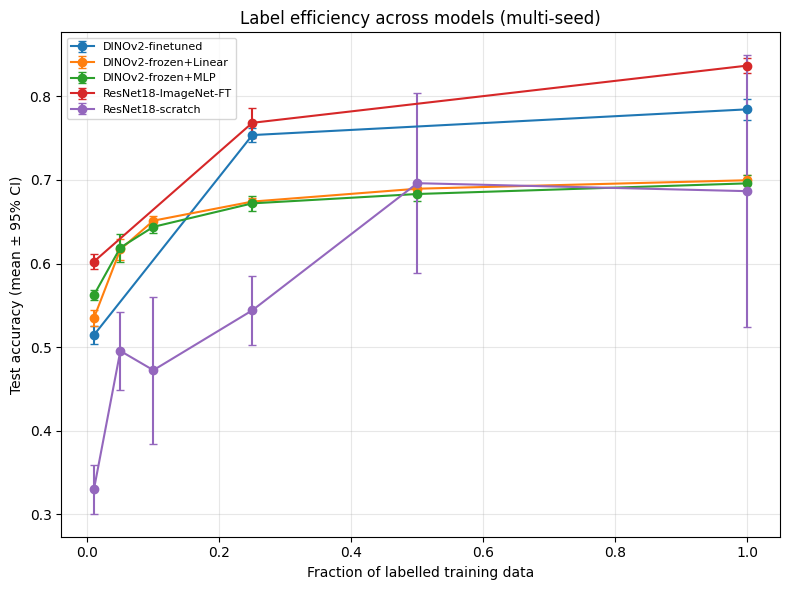

In [11]:
plt.figure(figsize=(8, 6))
for m, g in agg.groupby("model"):
    g = g.sort_values("fraction")
    plt.errorbar(g["fraction"], g["acc_mean"], yerr=g["acc_ci95"], marker="o", capsize=3, label=m)
plt.xlabel("Fraction of labelled training data")
plt.ylabel("Test accuracy (mean ± 95% CI)")
plt.title("Label efficiency across models (multi-seed)")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "label_efficiency_curve.png"), dpi=150)
plt.show()

## Step 9 — Statistical Significance Testing

**Why?**
Two average accuracies can differ simply by chance. A formal test tells us whether an observed gap is larger than what random variation across seeds would normally produce.

**What?**
For each label fraction where two models were run on all seeds, a paired t-test and a Wilcoxon signed-rank test on the per-seed accuracies, for two comparisons: **DINOv2-frozen+MLP vs. ResNet18-scratch** and **DINOv2-frozen+MLP vs. DINOv2-frozen+Linear**.

**How?**
`paired_tests()` lines up the two models' accuracies seed by seed (both saw the same labelled subset), and computes `ttest_rel` (assumes roughly bell-shaped differences) and `wilcoxon` (does not assume this). The column `significant_p<0.05` is based on the paired t-test.

> **In simple words:** The p-value answers "if the two models were really equally good, how surprising would this gap be?" A p-value below 0.05 is taken as evidence of a real difference.

**Points to keep in mind**
- With only 5 seeds, the smallest possible two-sided Wilcoxon p-value is 0.0625, so that test can never fall below 0.05 in the full run. This is why the significance flag uses the t-test; the Wilcoxon result is reported as a robustness check.
- The seeds are repeated trials on one fixed test set. The tests therefore speak about randomness in training and sampling, not about how the result would carry over to other galaxy datasets.

In [12]:
# Paired tests: for each seed both models were trained on the SAME labelled subset,
# so their accuracies are compared seed by seed.
def paired_tests(df, model_a, model_b, fraction):
    a = df[(df.model == model_a) & (df.fraction == fraction)].sort_values("seed")["accuracy"].values
    b = df[(df.model == model_b) & (df.fraction == fraction)].sort_values("seed")["accuracy"].values
    if len(a) != len(b) or len(a) < 2:
        return None
    t_stat, t_p = sstats.ttest_rel(a, b)
    try:
        w_stat, w_p = sstats.wilcoxon(a, b)
    except ValueError:
        w_stat, w_p = np.nan, np.nan
    return dict(model_a=model_a, model_b=model_b, fraction=fraction,
                mean_a=a.mean(), mean_b=b.mean(), diff=a.mean() - b.mean(),
                t_stat=t_stat, t_p=t_p, wilcoxon_stat=w_stat, wilcoxon_p=w_p)

comparisons = [("DINOv2-frozen+MLP", "ResNet18-scratch"),
               ("DINOv2-frozen+MLP", "DINOv2-frozen+Linear")]
sig_rows = []
for ma, mb in comparisons:
    for frac in FRACTIONS:
        res = paired_tests(per_run_df, ma, mb, frac)
        if res is not None:
            sig_rows.append(res)
sig_df = pd.DataFrame(sig_rows)
sig_df["significant_p<0.05"] = sig_df["t_p"] < 0.05
sig_df

,model_a,model_b,fraction,mean_a,mean_b,diff,t_stat,t_p,wilcoxon_stat,wilcoxon_p,significant_p<0.05
0,DINOv2-frozen+MLP,ResNet18-scratch,0.01,0.562333,0.329867,0.232467,14.369275,0.000136,0.0,0.0625,True
1,DINOv2-frozen+MLP,ResNet18-scratch,0.05,0.619067,0.495400,0.123667,5.360790,0.005843,0.0,0.0625,True
2,DINOv2-frozen+MLP,ResNet18-scratch,0.10,0.643867,0.472333,0.171533,3.897729,0.017575,0.0,0.0625,True
3,DINOv2-frozen+MLP,ResNet18-scratch,0.25,0.672000,0.544000,0.128000,5.571775,0.005084,0.0,0.0625,True
4,DINOv2-frozen+MLP,ResNet18-scratch,0.50,0.683200,0.696133,-0.012933,-0.246893,0.817145,5.0,0.6250,False
5,DINOv2-frozen+MLP,ResNet18-scratch,1.00,0.695933,0.686600,0.009333,0.112004,0.916216,5.0,0.6250,False
6,DINOv2-frozen+MLP,DINOv2-frozen+Linear,0.01,0.562333,0.534800,0.027533,5.469599,0.005436,0.0,0.0625,True
7,DINOv2-frozen+MLP,DINOv2-frozen+Linear,0.05,0.619067,0.616800,0.002267,0.360379,0.736788,5.0,0.6250,False
8,DINOv2-frozen+MLP,DINOv2-frozen+Linear,0.10,0.643867,0.651267,-0.007400,-1.137281,0.318925,5.0,0.6250,False
9,DINOv2-frozen+MLP,DINOv2-frozen+Linear,0.25,0.672000,0.674133,-0.002133,-0.346498,0.746428,7.0,1.0000,False


## Step 10 — Per-Class Precision, Recall and F1

**Why?**
Overall accuracy can hide poor performance on a rare or difficult class. Per-class scores show exactly where a model succeeds or fails.

**What?**
A table of precision, recall and F1 for each of the five classes, for the two headline models (frozen DINOv2 + MLP and ResNet-18 from scratch), using one representative run: 100% labels and the first seed.

**How?**
`per_class_table()` calls scikit-learn's `precision_score`, `recall_score` and `f1_score` with `average=None`, which returns one value per class.

> **In simple words:** *Precision* asks "when the model says Spiral, how often is it right?". *Recall* asks "of all real spirals, how many did the model find?". *F1* balances the two in a single number.

In [13]:
def per_class_table(y_true, y_pred, class_names):
    p = precision_score(y_true, y_pred, average=None, labels=range(len(class_names)), zero_division=0)
    r = recall_score(y_true, y_pred, average=None, labels=range(len(class_names)), zero_division=0)
    f = f1_score(y_true, y_pred, average=None, labels=range(len(class_names)), zero_division=0)
    return pd.DataFrame({"class": class_names, "precision": p, "recall": r, "f1": f})

# Representative run for each of the two headline models: 100% labels, first seed.
per_class_frames = {}
for m in ["DINOv2-frozen+MLP", "ResNet18-scratch"]:
    rec = next(r for r in records if r["model"] == m and r["fraction"] == 1.0 and r["seed"] == SEEDS[0])
    per_class_frames[m] = per_class_table(rec["y_true"], rec["preds"], CLASS_NAMES)
    print(f"\n=== {m} (100% labels, seed={SEEDS[0]}) ===")
    print(per_class_frames[m].round(3).to_string(index=False))


=== DINOv2-frozen+MLP (100% labels, seed=0) ===
              class  precision  recall    f1
       Round smooth      0.688   0.618 0.651
  In-between smooth      0.574   0.523 0.548
Cigar-shaped smooth      0.730   0.715 0.722
       Edge-on disk      0.773   0.793 0.783
             Spiral      0.727   0.860 0.788

=== ResNet18-scratch (100% labels, seed=0) ===
              class  precision  recall    f1
       Round smooth      0.675   0.963 0.794
  In-between smooth      0.701   0.650 0.675
Cigar-shaped smooth      0.696   0.870 0.773
       Edge-on disk      0.847   0.777 0.810
             Spiral      0.965   0.463 0.626


## Step 11 — Confusion Matrices

**Why?**
Per-class scores say *how well* each class is handled, but not *which* other class it is mixed up with. The confusion matrix shows this directly.

**What?**
Two heatmaps (one per headline model, same run as in Step 10). Rows are the true classes, columns are the predicted classes, and each cell counts galaxies.

**How?**
`confusion_matrix()` builds the table and `seaborn.heatmap` draws it with class names on both axes.

> **In simple words:** Numbers on the diagonal are correct predictions. Any large number away from the diagonal shows a pair of classes that the model finds hard to tell apart.

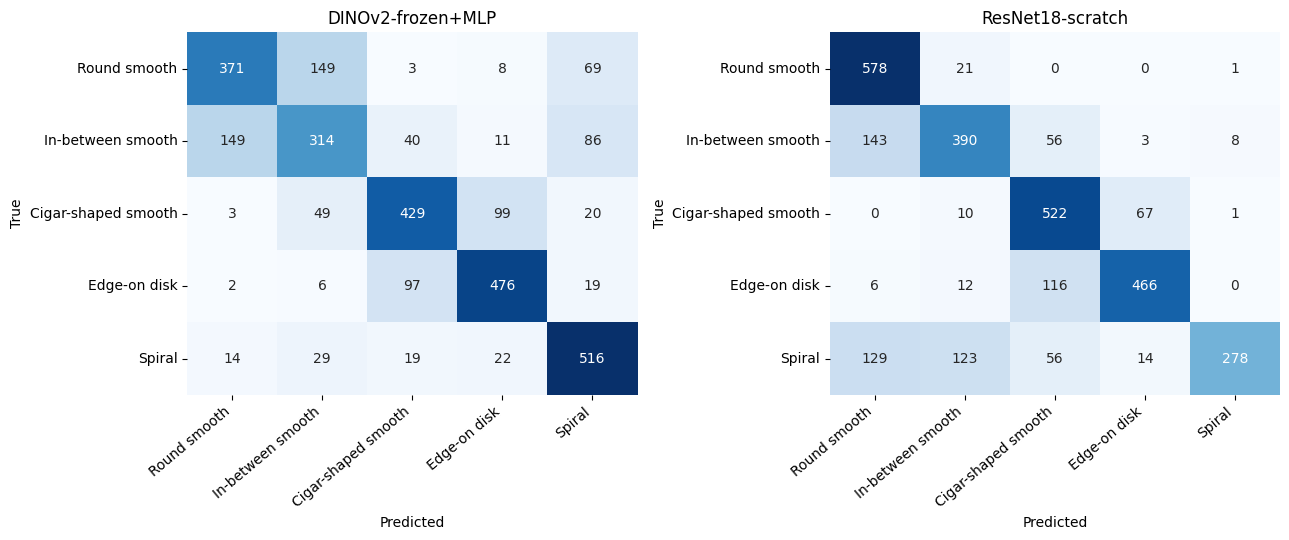

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, m in zip(axes, ["DINOv2-frozen+MLP", "ResNet18-scratch"]):
    rec = next(r for r in records if r["model"] == m and r["fraction"] == 1.0 and r["seed"] == SEEDS[0])
    cm = confusion_matrix(rec["y_true"], rec["preds"], labels=range(N_CLASSES))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(m); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.setp(ax.get_xticklabels(), rotation=40, ha="right")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "confusion_matrices.png"), dpi=150); plt.show()

## Step 12 — Error Analysis

**Why?**
Metrics tell us *how much* error there is; error analysis tells us *what kind* of error it is. This is the qualitative complement to the numbers above.

**What?**
For each headline model, the three classes with the lowest F1 and the three most frequent confusions (true class → predicted class).

**How?**
`error_analysis()` sorts the classes by F1 and picks the largest off-diagonal entries of the confusion matrix.

> **What to look for:** Some confusions are physically natural. Round, in-between and cigar-shaped smooth galaxies form a continuous range of ellipticity, so neighbouring classes may blur into each other. Compare the printed pairs with this expectation and comment on any surprises.

In [15]:
def error_analysis(y_true, y_pred, class_names, top_k=3):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    f1s = f1_score(y_true, y_pred, average=None, labels=range(len(class_names)), zero_division=0)
    worst_classes = np.argsort(f1s)[:top_k]
    print("Lowest-F1 classes:")
    for c in worst_classes:
        print(f"  {class_names[c]}: F1={f1s[c]:.3f}")

    off_diag = cm.copy().astype(float)
    np.fill_diagonal(off_diag, 0)
    flat_idx = np.dstack(np.unravel_index(np.argsort(-off_diag.ravel()), off_diag.shape))[0]
    print("\nMost-confused class pairs (true -> predicted, count):")
    shown = 0
    for i, j in flat_idx:
        if off_diag[i, j] <= 0:
            continue
        print(f"  {class_names[i]} -> {class_names[j]}: {int(off_diag[i, j])}")
        shown += 1
        if shown >= top_k:
            break

for m in ["DINOv2-frozen+MLP", "ResNet18-scratch"]:
    rec = next(r for r in records if r["model"] == m and r["fraction"] == 1.0 and r["seed"] == SEEDS[0])
    print(f"\n=== Error analysis: {m} ===")
    error_analysis(rec["y_true"], rec["preds"], CLASS_NAMES)


=== Error analysis: DINOv2-frozen+MLP ===
Lowest-F1 classes:
  In-between smooth: F1=0.548
  Round smooth: F1=0.651
  Cigar-shaped smooth: F1=0.722

Most-confused class pairs (true -> predicted, count):
  Round smooth -> In-between smooth: 149
  In-between smooth -> Round smooth: 149
  Cigar-shaped smooth -> Edge-on disk: 99

=== Error analysis: ResNet18-scratch ===
Lowest-F1 classes:
  Spiral: F1=0.626
  In-between smooth: F1=0.675
  Cigar-shaped smooth: F1=0.773

Most-confused class pairs (true -> predicted, count):
  In-between smooth -> Round smooth: 143
  Spiral -> Round smooth: 129
  Spiral -> In-between smooth: 123


## Step 13 — t-SNE of Frozen DINOv2 Embeddings

**Why?**
If DINOv2 has learnt useful features without labels, galaxies of the same class should end up close together in embedding space even though the model never saw a label.

**What?**
A 2-D scatter plot of the test-set embeddings coloured by true class. (A matching panel for the fine-tuned model is optional and is left out by default; see the note printed by the cell.)

**How?**
`TSNE(n_components=2, perplexity=30)` reduces the 384-number embeddings to two coordinates; points are coloured using the true labels.

> **In simple words:** t-SNE draws a map in which similar galaxies are placed near each other. Clearly separated coloured groups suggest that the features already capture morphology. Treat it as a picture for intuition only: distances between clusters and cluster sizes in a t-SNE plot should not be read too literally.

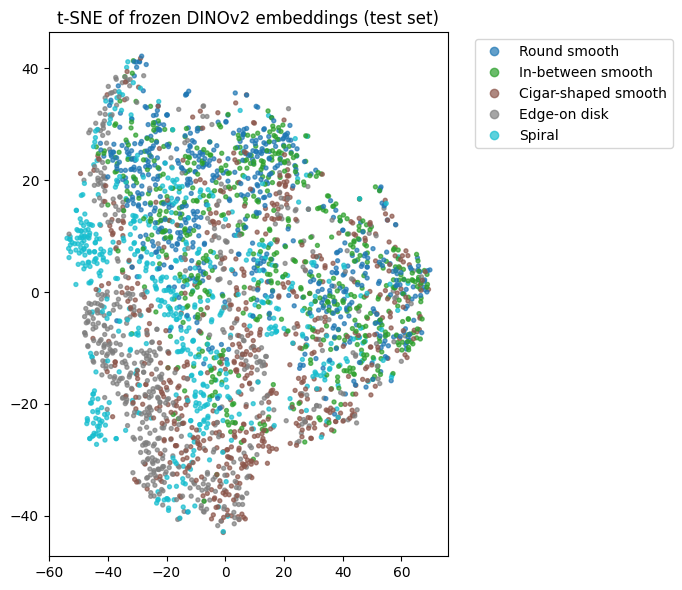

A fine-tuned DINOv2 model was trained at fraction=1.0. To see its t-SNE panel as well, re-extract its embeddings by passing test_ds through the fine-tuned backbone; this is left out by default to avoid an extra forward pass over the whole test set.


In [16]:
tsne = TSNE(n_components=2, random_state=0, perplexity=30)
emb_2d_frozen = tsne.fit_transform(test_feats)

plt.figure(figsize=(7, 6))
sc = plt.scatter(emb_2d_frozen[:, 0], emb_2d_frozen[:, 1], c=test_labels, cmap="tab10", s=8, alpha=0.7)
plt.legend(handles=sc.legend_elements()[0], labels=CLASS_NAMES, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("t-SNE of frozen DINOv2 embeddings (test set)")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "tsne_dinov2_frozen.png"), dpi=150); plt.show()

# Optional: the fine-tuned model's embeddings can be projected the same way (see the note printed below).
ft_rec = next((r for r in records if r["model"] == "DINOv2-finetuned" and r["fraction"] == 1.0), None)
if ft_rec is not None:
    print("A fine-tuned DINOv2 model was trained at fraction=1.0. To see its t-SNE panel as well, "
          "re-extract its embeddings by passing test_ds through the fine-tuned backbone; this is "
          "left out by default to avoid an extra forward pass over the whole test set.")

## Step 14 — Attention Visualisation (DINOv2)

**Why?**
We would like to check that the model looks at the galaxy itself and not at the background — a basic test of whether its features are meaningful.

**What?**
For one test image, the attention maps of the first six heads of the **last transformer block of the DINOv2 backbone** used in this notebook (not the older DINO ViT-S/8 model).

**How?**
- A forward hook on the block's `qkv` layer captures the query / key / value projections.
- The softmax attention is recomputed manually as *softmax(Q Kᵀ ÷ √d)*.
- The row for the `[CLS]` token (the token that summarises the image) is reshaped to the 16 × 16 patch grid and enlarged to 224 × 224.

> **In simple words:** An *attention map* highlights the parts of the picture that the model weighs most when forming its summary. Different heads often specialise in different things, so their maps differ. This is a qualitative check on a single image, not a proof.

In [17]:
# The DINOv2 backbone is needed here only for the attention maps (Notebook 1 used it for the embeddings).
dinov2_backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
dinov2_backbone.eval().to(DEVICE)
freeze(dinov2_backbone)

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


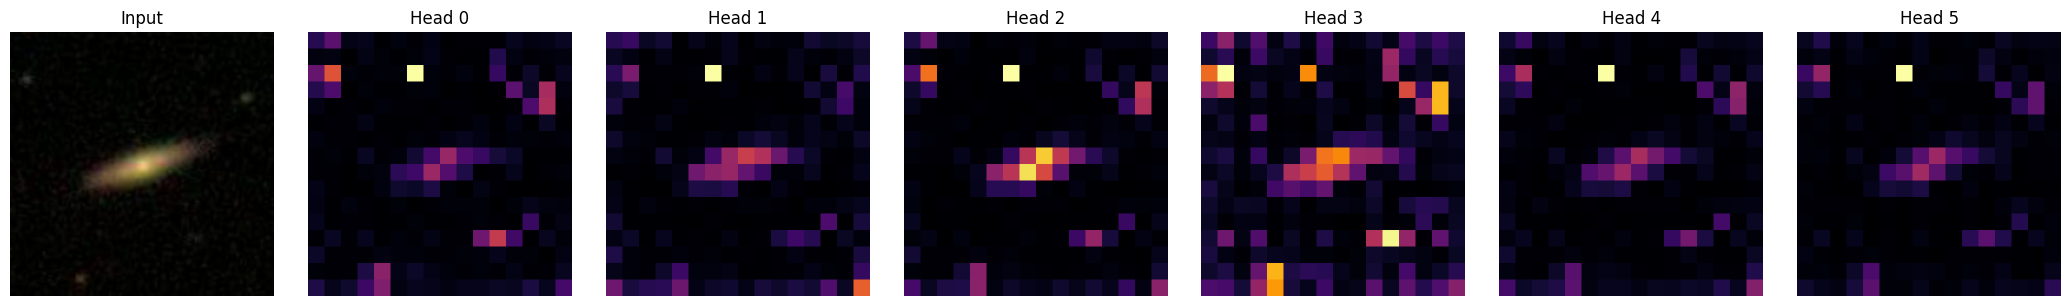

In [18]:
def extract_dinov2_attention(model, img_tensor, block_idx=-1, patch_size=14):
    block = model.blocks[block_idx]
    captured = {}
    def hook(module, inp, out):
        captured["qkv"] = out
    # A hook is a small function that grabs the 'qkv' (query-key-value) output of the last block
    # while the image passes through the model.
    h = block.attn.qkv.register_forward_hook(hook)
    with torch.no_grad():
        _ = model(img_tensor.unsqueeze(0).to(DEVICE))
    h.remove()

    qkv = captured["qkv"]                      # (1, N, 3*dim)
    B, N, three_c = qkv.shape
    num_heads = block.attn.num_heads
    head_dim = (three_c // 3) // num_heads
    qkv = qkv.reshape(B, N, 3, num_heads, head_dim).permute(2, 0, 3, 1, 4)
    q, k, _ = qkv[0], qkv[1], qkv[2]
    # Attention = softmax(Q K^T / sqrt(d)); row 0 belongs to the [CLS] token, which summarises the image.
    attn = (q @ k.transpose(-2, -1)) * (head_dim ** -0.5)
    attn = attn.softmax(dim=-1)[0]              # (num_heads, N, N)

    n_patches = N - 1
    grid = int(round(math.sqrt(n_patches)))
    cls_attn = attn[:, 0, 1:].reshape(num_heads, grid, grid)
    cls_attn = F.interpolate(cls_attn.unsqueeze(0), scale_factor=patch_size, mode="nearest")[0]
    return cls_attn.cpu().numpy()

sample_img, sample_label = test_ds[0]
attn_maps = extract_dinov2_attention(dinov2_backbone, sample_img)

n_heads_to_show = min(6, attn_maps.shape[0])
fig, axes = plt.subplots(1, n_heads_to_show + 1, figsize=(3 * (n_heads_to_show + 1), 3))
img_disp = sample_img.permute(1, 2, 0).numpy()
img_disp = (img_disp * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)).clip(0, 1)
axes[0].imshow(img_disp); axes[0].set_title("Input"); axes[0].axis("off")
for i in range(n_heads_to_show):
    axes[i + 1].imshow(attn_maps[i], cmap="inferno")
    axes[i + 1].set_title(f"Head {i}"); axes[i + 1].axis("off")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "attention_maps_dinov2.png"), dpi=150); plt.show()

## Step 15 — Computational Efficiency Comparison

**Why?**
In practice accuracy is not the only concern. A slightly less accurate model that trains in seconds and needs little memory may be the better choice for a large survey.

**What?**
For each model: number of trainable parameters, mean training time, mean inference time per image and mean peak GPU memory.

**How?**
The efficiency measurements stored in `per_run_df` are grouped by model and averaged.

**How to read this table fairly**
- **Probes count only their own small head.** For frozen-DINOv2 models the table lists the probe's trainable parameters (1,925 for the linear probe and 99,845 for the MLP probe) and times only the probe. The backbone's roughly 21 million frozen parameters and the one-time embedding extraction (`dino_extract_time`, Step 6b) are *not* included.
- **Inference time is not like-for-like.** Probes are timed on ready-made embeddings, whereas CNN and fine-tuned-DINOv2 timings include the full image pass through the network.
- **Averages mix different fractions.** Models 4 and 5 were run at only three fractions, and training time grows with the number of labelled images. Filter to a single fraction (for example 100%) before comparing training times.
- **Memory:** peak GPU memory was recorded only for the models trained end to end on the GPU (models 3, 4 and 5); missing values are shown as 0 and simply mean "not measured".

In [19]:
# NOTE: probes are timed on pre-computed embeddings only; see the notes in Step 15 before comparing.
eff = per_run_df.groupby("model").agg(
    mean_train_time_s=("train_time", "mean"),
    mean_infer_time_per_img_ms=("infer_time", lambda x: x.mean() * 1000),
    n_params=("n_params", "first"),
    mean_peak_mem_mb=("peak_mem_mb", "mean"),
).reset_index()
eff["mean_peak_mem_mb"] = eff["mean_peak_mem_mb"].fillna(0)
eff

,model,mean_train_time_s,mean_infer_time_per_img_ms,n_params,mean_peak_mem_mb
0,DINOv2-finetuned,294.919404,5.324596,3552389,790.775330
1,DINOv2-frozen+Linear,3.527813,0.000777,1925,0.000000
2,DINOv2-frozen+MLP,4.239774,0.001097,99845,0.000000
3,ResNet18-ImageNet-FT,395.328405,4.061178,11179077,1849.047142
4,ResNet18-scratch,300.050084,4.002351,11179077,1845.327838


## Step 16 — Ablation Studies

**Why?**
An ablation removes or changes *one* ingredient at a time, so that we can say which design choice is responsible for a gain.

**What?**
- **(a) Frozen vs. fine-tuned DINOv2** — the effect of unfreezing the last transformer blocks.
- **(b) MLP probe vs. linear probe** — the effect of probe capacity and non-linearity, with the representation kept fixed.

**How?**
Two side-by-side label-efficiency plots (accuracy with 95% CI against label fraction), built from the same `agg` table.

**Caution for (a):** the fine-tuned model is also trained with data augmentation, whereas the probes use pre-computed, non-augmented embeddings, and the fine-tuned model was run at three fractions only. The comparison therefore bundles a few differences together; interpret it as "frozen probe vs. fine-tuned model" rather than a perfectly isolated effect of unfreezing.

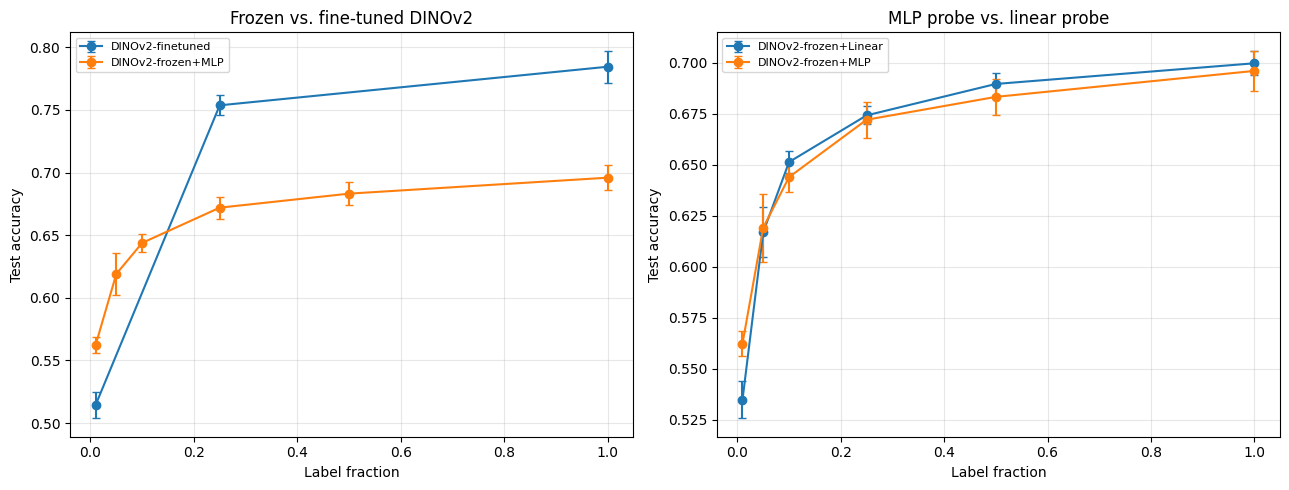

In [20]:
ablation_a = agg[agg.model.isin(["DINOv2-frozen+MLP", "DINOv2-finetuned"])]
ablation_b = agg[agg.model.isin(["DINOv2-frozen+MLP", "DINOv2-frozen+Linear"])]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, abl, title in [(axes[0], ablation_a, "Frozen vs. fine-tuned DINOv2"),
                        (axes[1], ablation_b, "MLP probe vs. linear probe")]:
    for m, g in abl.groupby("model"):
        g = g.sort_values("fraction")
        ax.errorbar(g["fraction"], g["acc_mean"], yerr=g["acc_ci95"], marker="o", capsize=3, label=m)
    ax.set_xlabel("Label fraction"); ax.set_ylabel("Test accuracy"); ax.set_title(title)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "ablation_studies.png"), dpi=150); plt.show()

## Step 17 — Comparison with AstroDINO's Reported Numbers

**Why?**
Placing our results next to the source paper's shows whether our findings point in the same direction.

**What?**
A side-by-side view of AstroDINO's reported Top-1 accuracies and our own accuracies at 100% labels.

**How?**
The table below is quoted from the paper; the code cell prints our `agg` results for the largest label fraction.

**Important caveat.** AstroDINO reports Top-1 accuracy for DINOv2 ViT-L/14 and ViT-S/14 on a **10-class** Galaxy Zoo task derived differently from ours (their labels come from an `argmax` over the MultimodalUniverse GZ2 10-column encoding, evaluated on DESI Legacy Survey cut-outs). Our task uses a different, independently documented 5-class scheme with an explicit reliability cut, so the numbers are **not directly comparable**. They are included as context, not as a benchmark to beat.

| Model (AstroDINO, 10-class task) | Reported Top-1 Accuracy |
|---|---|
| DINOv2 ViT-L/14 | 73% |
| DINOv2 ViT-S/14 | 67% |
| EfficientNetB0 (no pretraining) | 81% |
| ResNet-18 (no pretraining) | 73% |
| DenseNet121 (no pretraining) | 74% |

Our own results at 100% labels (Step 8) are printed below for side-by-side reference.

In [21]:
print(agg[agg.fraction == agg.fraction.max()][["model", "acc_mean", "acc_std", "n_runs"]]
      .to_string(index=False))

               model  acc_mean  acc_std  n_runs
    DINOv2-finetuned  0.784533 0.014599       5
DINOv2-frozen+Linear  0.699667 0.006778       5
   DINOv2-frozen+MLP  0.695933 0.011283       5
ResNet18-ImageNet-FT  0.836867 0.009766       5
    ResNet18-scratch  0.686600 0.185556       5


## Step 18 — Auto-Generated Results Summary

**Why?**
Writing the discussion by hand risks mismatches between the text and the actual numbers. Generating the sentences from the computed tables avoids this.

**What?**
Short narrative statements: accuracy of frozen DINOv2 + MLP against ResNet-18 from scratch at full and at the lowest label fraction, the gap between them in percentage points, and whether the low-label difference is statistically significant.

**How?**
The cell reads the `agg` and `sig_df` tables, formats the values as percentages and prints the sentences. Run it last and copy its output into the paper's Discussion section.

In [22]:
def fmt_pct(x): return f"{100*x:.1f}%"      # e.g. 0.731 -> "73.1%"
def fmt_pp(x): return f"{100*x:.1f}"         # e.g. 0.123 -> "12.3" (used before the words "percentage points")

best_frac = agg["fraction"].max()
worst_frac = agg["fraction"].min()

def get(model, frac, col):
    row = agg[(agg.model == model) & (agg.fraction == frac)]
    return row[col].values[0] if len(row) else float("nan")

summary_lines = []
summary_lines.append(
    f"At full label availability ({fmt_pct(best_frac)} of the training set), the frozen "
    f"DINOv2 + MLP probe reached {fmt_pct(get('DINOv2-frozen+MLP', best_frac, 'acc_mean'))} "
    f"(± {get('DINOv2-frozen+MLP', best_frac, 'acc_std'):.3f} std over {SEEDS.__len__()} seeds) "
    f"test accuracy, versus {fmt_pct(get('ResNet18-scratch', best_frac, 'acc_mean'))} for the "
    f"from-scratch ResNet-18."
)
summary_lines.append(
    f"At the lowest label fraction tested ({fmt_pct(worst_frac)}), frozen DINOv2 + MLP reached "
    f"{fmt_pct(get('DINOv2-frozen+MLP', worst_frac, 'acc_mean'))} versus "
    f"{fmt_pct(get('ResNet18-scratch', worst_frac, 'acc_mean'))} for the from-scratch CNN — a gap of "
    f"{fmt_pp(get('DINOv2-frozen+MLP', worst_frac, 'acc_mean') - get('ResNet18-scratch', worst_frac, 'acc_mean'))} "
    f"percentage points, versus a gap of "
    f"{fmt_pp(get('DINOv2-frozen+MLP', best_frac, 'acc_mean') - get('ResNet18-scratch', best_frac, 'acc_mean'))} "
    f"percentage points at full labels."
)
sig_row = sig_df[(sig_df.model_a == "DINOv2-frozen+MLP") & (sig_df.model_b == "ResNet18-scratch")
                  & (sig_df.fraction == worst_frac)]
if len(sig_row):
    p = sig_row["t_p"].values[0]
    summary_lines.append(
        f"This difference at {fmt_pct(worst_frac)} labels is "
        f"{'statistically significant (p = %.4f < 0.05, paired t-test)' % p if p < 0.05 else 'not statistically significant (p = %.4f, paired t-test)' % p}."
    )

print("\n".join(summary_lines))

At full label availability (100.0% of the training set), the frozen DINOv2 + MLP probe reached 69.6% (± 0.011 std over 5 seeds) test accuracy, versus 68.7% for the from-scratch ResNet-18.
At the lowest label fraction tested (1.0%), frozen DINOv2 + MLP reached 56.2% versus 33.0% for the from-scratch CNN — a gap of 23.2 percentage points, versus a gap of 0.9 percentage points at full labels.
This difference at 1.0% labels is statistically significant (p = 0.0001 < 0.05, paired t-test).


## Limitations and Future Work

**Limitations**
- **Single survey and small subset.** All results come from one dataset (GZ2), a 5-class scheme and a class-balanced subset of at most 20,000 galaxies.
- **Only the smallest DINOv2.** ViT-S/14 is used; larger backbones (ViT-B, ViT-L, ViT-g) are not tested.
- **Clean-sample bias.** Ambiguous galaxies are dropped, so the reported accuracy applies to confidently labelled galaxies and will look better than performance on *all* galaxies. Volunteer labels themselves also contain noise.
- **No hyperparameter tuning.** Learning rates and epoch counts are fixed; the validation set is not used for model selection.
- **Reduced grid for two models.** ResNet-18 (ImageNet fine-tuned) and the fine-tuned DINOv2 run at only three label fractions, and they are not part of the significance tests in Step 9.
- **Few seeds.** With 5 seeds the confidence intervals are approximate and the Wilcoxon test has limited power.
- **Timing noise.** Training and inference times measured on shared Colab GPUs vary between sessions.

**Future work**
- Extend the significance tests to the fine-tuned and ImageNet-pretrained models on the full fraction grid.
- Add the t-SNE panel of the fine-tuned model and a k-nearest-neighbour probe.
- Tune hyperparameters on the validation set and test larger DINOv2 backbones.
- Repeat the study on other galaxy surveys (for example DECaLS or DESI) to check how well the conclusions carry over.

## References

1. M. Caron et al., "Emerging Properties in Self-Supervised Vision Transformers," arXiv:2104.14294, 2021.
2. M. Oquab et al., "DINOv2: Learning Robust Visual Features without Supervision," arXiv:2304.07193, 2023.
3. V. Manwadkar and S. Kapare, "AstroDINO: Self-Supervised Learning on Astronomical Images," Stanford University, 2025. *(Source paper — pipeline reproduced and extended here.)*
4. B. Willett et al., "Galaxy Zoo 2: detailed morphological classifications for 304,122 galaxies from the Sloan Digital Sky Survey," MNRAS, 435(3):2835–2860, 2013.
5. R. Hart et al., "Galaxy Zoo: comparing the demographics of spiral arm number and a new method for correcting redshift bias," MNRAS, 461(4):3663–3682, 2016.
6. A. Dey et al., "Overview of the DESI Legacy Imaging Surveys," AJ, 157(5):168, 2019.
7. The Multimodal Universe Collaboration et al., "The Multimodal Universe," arXiv:2412.02527, 2024.
8. M. Walmsley et al., "Galaxy Zoo DECaLS: Detailed visual morphology measurements," MNRAS, 509(3):3966–3988, 2022 (galaxy-datasets / Zoobot package).
9. K. He et al., "Deep Residual Learning for Image Recognition," CVPR, 2016.

## Save All Tables to Google Drive

**Why?** The figures were already saved to `figures/` as they were drawn. The tables, however, exist only in the notebook's memory. Saving them as CSV files lets you build the report or reload them later without re-running anything. **What?** `per_run_df`, `agg`, `sig_df`, `eff`, the per-class tables and the auto-generated summary text, all written to `results/` on Drive.

In [23]:
per_run_df.to_csv(f"{RES_DIR}/per_run_results.csv", index=False)
agg.to_csv(f"{RES_DIR}/aggregated_results.csv", index=False)
sig_df.to_csv(f"{RES_DIR}/significance_tests.csv", index=False)
eff.to_csv(f"{RES_DIR}/computational_efficiency.csv", index=False)
for m, df_pc in per_class_frames.items():
    df_pc.to_csv(f"{RES_DIR}/per_class_{m.replace('+', '_')}.csv", index=False)
with open(f"{RES_DIR}/auto_summary.txt", "w") as f:
    f.write("\n".join(summary_lines))

print("Saved to", RES_DIR)
for name in sorted(os.listdir(RES_DIR)):
    print("  ", name)
print("\nFigures in", FIG_DIR)
for name in sorted(os.listdir(FIG_DIR)):
    print("  ", name)

Saved to /content/drive/MyDrive/galaxy_project/full/results
   aggregated_results.csv
   auto_summary.txt
   computational_efficiency.csv
   per_class_DINOv2-frozen_MLP.csv
   per_class_ResNet18-scratch.csv
   per_run_results.csv
   significance_tests.csv

Figures in /content/drive/MyDrive/galaxy_project/full/figures
   ablation_studies.png
   attention_maps_dinov2.png
   class_distribution.png
   confusion_matrices.png
   label_efficiency_curve.png
   nb1_probe_preview.png
   tsne_dinov2_frozen.png


### Final cell — flush Google Drive
Drive writes are buffered. Running this cell (last) forces every file to be written before you close the tab. After it runs, Drive is unmounted — that is expected.

In [24]:
from google.colab import drive
drive.flush_and_unmount()
print("Drive flushed. The project is complete -- all results are in", PROJECT_DIR)

Drive flushed. The project is complete -- all results are in /content/drive/MyDrive/galaxy_project/full
